# Flight Booking System — Data Visualizations

**All data read exclusively from MongoDB (flight_nosql)**

Visualizations:
1. World Flight Route Map
2. Revenue per km by Route (Top 20)
3. Occupancy Rate Distribution by Flight Status
4. Passenger Loyalty Tier Breakdown
5. Delay Minutes vs Average Review Score

In [15]:
# ── Imports & MongoDB connection ─────────────────────────────────────────────
import os
import sys
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from db import get_mongo_client, get_mongo_db

load_dotenv('../.env')

client   = get_mongo_client()
mongo_db = get_mongo_db(client)

print('Connected to MongoDB:', mongo_db.name)
for col in ['airports','airlines','flights','passengers','bookings']:
    print(f'  {col:<15} {mongo_db[col].count_documents({}):>6,} documents')

Connected to MongoDB: flight_nosql
  airports         1,800 documents
  airlines           990 documents
  flights          2,500 documents
  passengers       3,500 documents
  bookings        12,000 documents


---
## Visualization 1 — World Flight Route Map

Plots flight routes as arcs on a world map using origin/destination coordinates.
Uses the **denormalized** origin and destination data embedded during migration.

In [16]:
# Step 1 — build airport coordinate lookup from MongoDB airports collection
ap_cursor = mongo_db['airports'].find(
    {},
    {'iata_code': 1, 'city': 1, 'location.coordinates': 1, '_id': 0}
)
ap_coords = {}  # iata_code -> (lon, lat, city)
for ap in ap_cursor:
    coords = ap.get('location', {}).get('coordinates', [])
    if len(coords) == 2:
        ap_coords[ap['iata_code']] = (coords[0], coords[1], ap.get('city', ''))

print(f'Airport coords loaded: {len(ap_coords)}')

# Step 2 — fetch flights with origin/destination IATA codes
fl_cursor = mongo_db['flights'].find(
    {'status': {'$in': ['completed', 'scheduled']}},
    {'flight_number': 1, 'airline.name': 1,
     'origin.iata_code': 1, 'origin.city': 1,
     'destination.iata_code': 1, 'destination.city': 1,
     'stats.occupancy_rate': 1, '_id': 0}
).limit(300)

# Step 3 — join coordinates in Python
flights_geo = []
for f in fl_cursor:
    orig_iata = f.get('origin', {}).get('iata_code')
    dest_iata = f.get('destination', {}).get('iata_code')
    if orig_iata in ap_coords and dest_iata in ap_coords:
        flights_geo.append({
            'flight_number': f.get('flight_number'),
            'airline':       f.get('airline', {}).get('name'),
            'origin_iata':   orig_iata,
            'dest_iata':     dest_iata,
            'origin_city':   f.get('origin', {}).get('city'),
            'dest_city':     f.get('destination', {}).get('city'),
            'origin_lon':    ap_coords[orig_iata][0],
            'origin_lat':    ap_coords[orig_iata][1],
            'dest_lon':      ap_coords[dest_iata][0],
            'dest_lat':      ap_coords[dest_iata][1],
            'occupancy':     f.get('stats', {}).get('occupancy_rate', 0),
        })

print(f'Flights with valid coordinates: {len(flights_geo)}')

Airport coords loaded: 1800
Flights with valid coordinates: 300


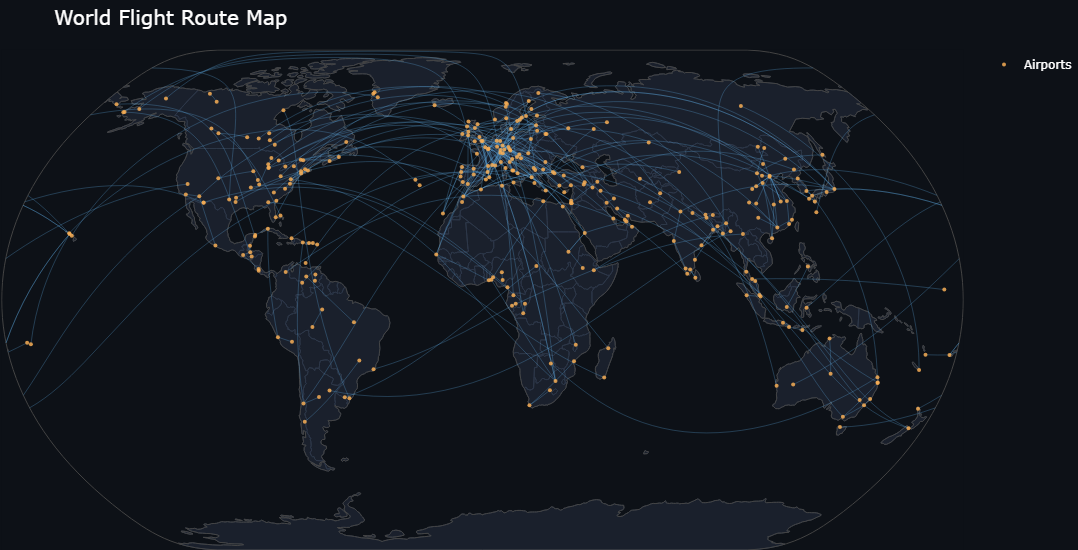

In [17]:
fig = go.Figure()

# Draw route arcs
for f in flights_geo:
    try:
        fig.add_trace(go.Scattergeo(
            lon=[f['origin_lon'], f['dest_lon']],
            lat=[f['origin_lat'], f['dest_lat']],
            mode='lines',
            line=dict(width=0.8, color='rgba(99,179,237,0.35)'),
            showlegend=False,
            hoverinfo='skip',
        ))
    except (KeyError, TypeError):
        continue

# Draw airport dots
airport_coords = {}
for f in flights_geo:
    try:
        airport_coords[f['origin_iata']] = (f['origin_lon'], f['origin_lat'], f['origin_city'])
        airport_coords[f['dest_iata']]   = (f['dest_lon'],   f['dest_lat'],   f['dest_city'])
    except KeyError:
        continue

if airport_coords:
    lons, lats, labels = zip(*[(v[0], v[1], f"{k} — {v[2]}") for k, v in airport_coords.items()])
    fig.add_trace(go.Scattergeo(
        lon=lons, lat=lats,
        mode='markers',
        marker=dict(size=4, color='#F6AD55', opacity=0.85),
        text=labels,
        hovertemplate='%{text}<extra></extra>',
        name='Airports',
    ))

fig.update_layout(
    title=dict(text='World Flight Route Map', font=dict(size=20)),
    geo=dict(
        showland=True, landcolor='#1a202c',
        showocean=True, oceancolor='#0d1117',
        showlakes=False,
        showcountries=True, countrycolor='#2d3748',
        bgcolor='#0d1117',
        projection_type='natural earth',
    ),
    paper_bgcolor='#0d1117',
    font_color='white',
    height=550,
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()

---
## Visualization 2 — Revenue per km by Route (Top 20)

Uses the **derived field `revenue_per_km`** computed during migration.
Shows which routes generate the most revenue relative to their distance.

In [18]:
pipeline = [
    {"$match": {
        "stats.revenue_per_km": {"$gt": 0},
        "stats.distance_km":    {"$gt": 500},   # filter very short routes
        "stats.total_bookings": {"$gt": 2},     # at least 3 bookings
    }},
    {"$project": {
        "route": {"$concat": [
            "$origin.city", " (", "$origin.iata_code", ")",
            " → ",
            "$destination.city", " (", "$destination.iata_code", ")"
        ]},
        "airline":         "$airline.name",
        "revenue_per_km":  "$stats.revenue_per_km",
        "distance_km":     "$stats.distance_km",
        "total_bookings":  "$stats.total_bookings",
        "occupancy_rate":  "$stats.occupancy_rate",
        "price_category":  "$pricing.price_category",
    }},
    {"$sort": {"revenue_per_km": -1}},
    {"$limit": 20},
]

rev_km_data = list(mongo_db['flights'].aggregate(pipeline))
df_rev = pd.DataFrame(rev_km_data)
print(f'Loaded {len(df_rev)} flights for revenue/km chart')
df_rev[['route','airline','revenue_per_km','distance_km','price_category']].head(5)


Loaded 20 flights for revenue/km chart


,route,airline,revenue_per_km,distance_km,price_category
0,Nagoya (NGO) → Kumamoto (KMJ),All Nippon Airways,4.1549,593,standard
1,Hohhot (HET) → Guangzhou (CAN),Shenzhen Airlines,3.3065,1946,standard
2,Zunyi (ZYI) → Xiamen (XMN),Air Foyle,2.9471,1161,standard
3,Casablanca (CMN) → Berlin (TXL),Royal Air Maroc,2.7781,2706,premium
4,Agana (GUM) → Nagoya (NGO),Delta Air Lines,2.7755,2508,premium


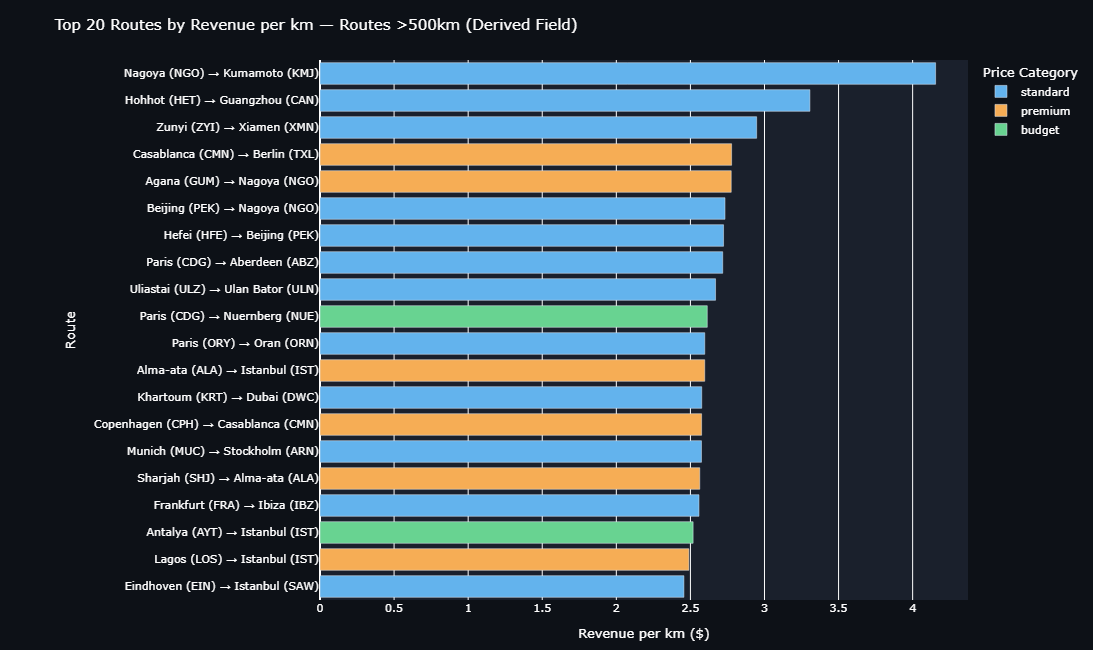

In [19]:
fig2 = px.bar(
    df_rev,
    x='revenue_per_km',
    y='route',
    orientation='h',
    color='price_category',
    hover_data=['airline', 'distance_km', 'total_bookings', 'occupancy_rate'],
    color_discrete_map={
        'budget':   '#68D391',
        'standard': '#63B3ED',
        'premium':  '#F6AD55',
    },
    labels={
        'revenue_per_km': 'Revenue per km ($)',
        'route':          'Route',
        'price_category': 'Price Category',
    },
    title='Top 20 Routes by Revenue per km — Routes >500km (Derived Field)',
)
fig2.update_layout(
    height=650,
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title='Revenue per km ($)',
    plot_bgcolor='#1a202c',
    paper_bgcolor='#0d1117',
    font_color='white',
    font=dict(size=11),
    margin=dict(l=320, r=40, t=60, b=40),
)
fig2.show()


---
## Visualization 3 — Occupancy Rate Distribution by Flight Status

Uses the **derived field `occupancy_rate`** (active bookings / total seats × 100).
Shows how seat utilization differs across flight statuses.

In [20]:
pipeline = [
    {"$match": {
        "stats.occupancy_rate": {"$gt": 0},
        "status": {"$in": ["completed", "delayed", "scheduled"]}
    }},
    {"$project": {
        "status":         1,
        "occupancy_rate": "$stats.occupancy_rate",
        "total_bookings": "$stats.total_bookings",
        "price_category": "$pricing.price_category",
    }}
]

occ_data = list(mongo_db['flights'].aggregate(pipeline))
df_occ   = pd.DataFrame(occ_data)
print(f'Loaded {len(df_occ)} flights')
print('\nOccupancy rate stats by status (note: low % reflects avg 4-5 bookings per flight across 2500 flights):')
print(df_occ.groupby('status')['occupancy_rate'].describe().round(2))
print('\nAvg bookings per flight:', df_occ['total_bookings'].mean().round(1))


Loaded 2352 flights

Occupancy rate stats by status (note: low % reflects avg 4-5 bookings per flight across 2500 flights):
            count  mean   std   min   25%   50%   75%    max
status                                                      
completed  1472.0  2.10  1.70  0.18  0.98  1.64  2.75  12.09
delayed     252.0  1.99  1.58  0.25  0.90  1.47  2.69  10.11
scheduled   628.0  1.95  1.45  0.18  0.95  1.52  2.70   8.79

Avg bookings per flight: 4.3


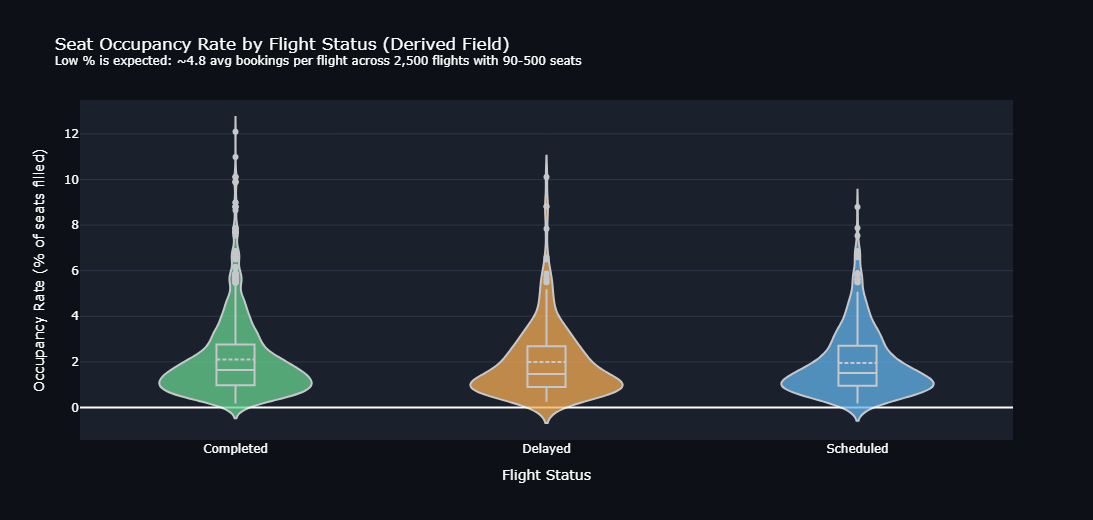

In [21]:
status_colors = {
    'completed':  '#68D391',
    'scheduled':  '#63B3ED',
    'delayed':    '#F6AD55',
    'cancelled':  '#FC8181',
}

fig3 = go.Figure()
for status, group in df_occ.groupby('status'):
    fig3.add_trace(go.Violin(
        y=group['occupancy_rate'],
        name=status.capitalize(),
        box_visible=True,
        meanline_visible=True,
        fillcolor=status_colors.get(status, '#A0AEC0'),
        opacity=0.75,
        line_color='white',
        points='outliers',
    ))

fig3.update_layout(
    title='Seat Occupancy Rate by Flight Status (Derived Field)<br>'
          '<sup>Low % is expected: ~4.8 avg bookings per flight across 2,500 flights with 90-500 seats</sup>',
    yaxis_title='Occupancy Rate (% of seats filled)',
    xaxis_title='Flight Status',
    plot_bgcolor='#1a202c',
    paper_bgcolor='#0d1117',
    font_color='white',
    height=520,
    showlegend=False,
)
fig3.update_yaxes(gridcolor='#2d3748')
fig3.show()


---
## Visualization 4 — Passenger Loyalty Tier Breakdown

Uses the **derived field `loyalty_tier`** and **`total_spent`** computed during migration.
Shows tier distribution and average spending per tier.

In [22]:
pipeline = [
    {"$group": {
        "_id":         "$loyalty.tier",
        "count":       {"$sum": 1},
        "avg_spent":   {"$avg": "$loyalty.total_spent"},
        "avg_flights": {"$avg": "$loyalty.total_flights"},
        "avg_points":  {"$avg": "$loyalty.points"},
    }},
    {"$sort": {"avg_spent": 1}}
]

tier_data = list(mongo_db['passengers'].aggregate(pipeline))
df_tier   = pd.DataFrame(tier_data).rename(columns={'_id': 'tier'})
df_tier['avg_spent']   = df_tier['avg_spent'].round(2)
df_tier['avg_flights'] = df_tier['avg_flights'].round(1)
df_tier['avg_points']  = df_tier['avg_points'].round(0)
print(df_tier)

     tier  count  avg_spent  avg_flights  avg_points
0  bronze   2913    1205.31          2.4       356.0
1  silver    587    2815.29          5.7       849.0


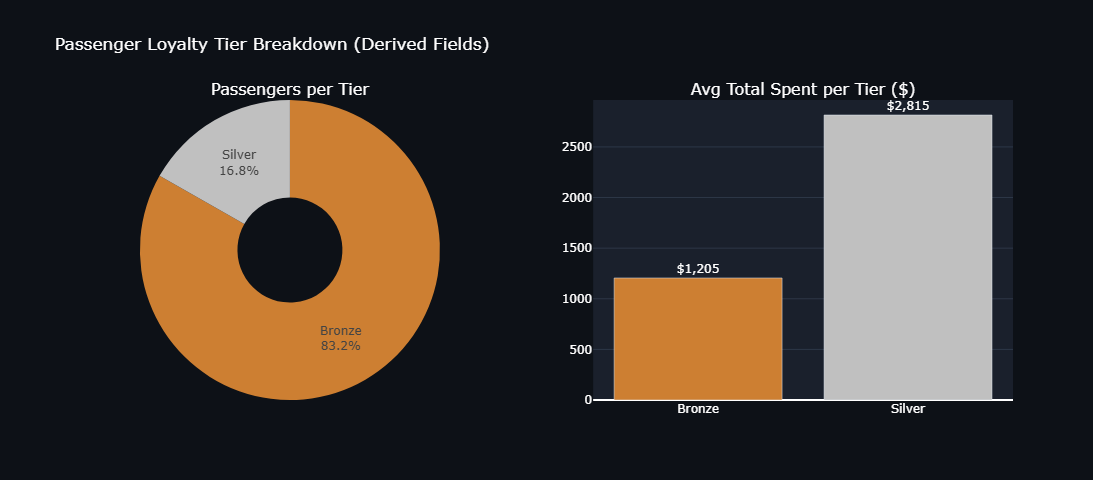

In [23]:
tier_colors = {
    'bronze':   '#CD7F32',
    'silver':   '#C0C0C0',
    'gold':     '#FFD700',
    'platinum': '#E5E4E2',
}

fig4 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Passengers per Tier', 'Avg Total Spent per Tier ($)'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}]]
)

# Pie — passenger count per tier
fig4.add_trace(
    go.Pie(
        labels=df_tier['tier'].str.capitalize(),
        values=df_tier['count'],
        marker_colors=[tier_colors.get(t, '#A0AEC0') for t in df_tier['tier']],
        textinfo='label+percent',
        hole=0.35,
    ),
    row=1, col=1
)

# Bar — avg spend per tier
fig4.add_trace(
    go.Bar(
        x=df_tier['tier'].str.capitalize(),
        y=df_tier['avg_spent'],
        marker_color=[tier_colors.get(t, '#A0AEC0') for t in df_tier['tier']],
        text=df_tier['avg_spent'].apply(lambda x: f'${x:,.0f}'),
        textposition='outside',
        customdata=df_tier[['avg_flights', 'avg_points']].values,
        hovertemplate=(
            'Tier: %{x}<br>'
            'Avg Spent: $%{y:,.2f}<br>'
            'Avg Flights: %{customdata[0]}<br>'
            'Avg Points: %{customdata[1]}<extra></extra>'
        ),
    ),
    row=1, col=2
)

fig4.update_layout(
    title='Passenger Loyalty Tier Breakdown (Derived Fields)',
    plot_bgcolor='#1a202c',
    paper_bgcolor='#0d1117',
    font_color='white',
    height=480,
    showlegend=False,
)
fig4.update_yaxes(gridcolor='#2d3748', row=1, col=2)
fig4.show()

---
## Visualization 5 — Delay Minutes vs Average Review Score

Uses **derived fields `avg_review_score`** and delay data embedded during migration.
Shows whether longer delays correlate with lower passenger satisfaction.

In [24]:
pipeline = [
    {"$match": {
        "delay":                   {"$ne": None},
        "stats.avg_review_score":  {"$gt": 0},
        "delay.delay_minutes":     {"$gt": 0},
    }},
    {"$project": {
        "flight_number":    1,
        "delay_minutes":    "$delay.delay_minutes",
        "delay_reason":     "$delay.reason",
        "avg_review_score": "$stats.avg_review_score",
        "occupancy_rate":   "$stats.occupancy_rate",
        "airline":          "$airline.name",
        "status":           1,
    }}
]

delay_data = list(mongo_db['flights'].aggregate(pipeline))
df_delay   = pd.DataFrame(delay_data)
print(f'Loaded {len(df_delay)} delayed flights with reviews')
print(f"Delay range: {df_delay['delay_minutes'].min()}–{df_delay['delay_minutes'].max()} min")
print(f"Review range: {df_delay['avg_review_score'].min():.2f}–{df_delay['avg_review_score'].max():.2f}")

Loaded 519 delayed flights with reviews
Delay range: 5–299 min
Review range: 1.00–5.00


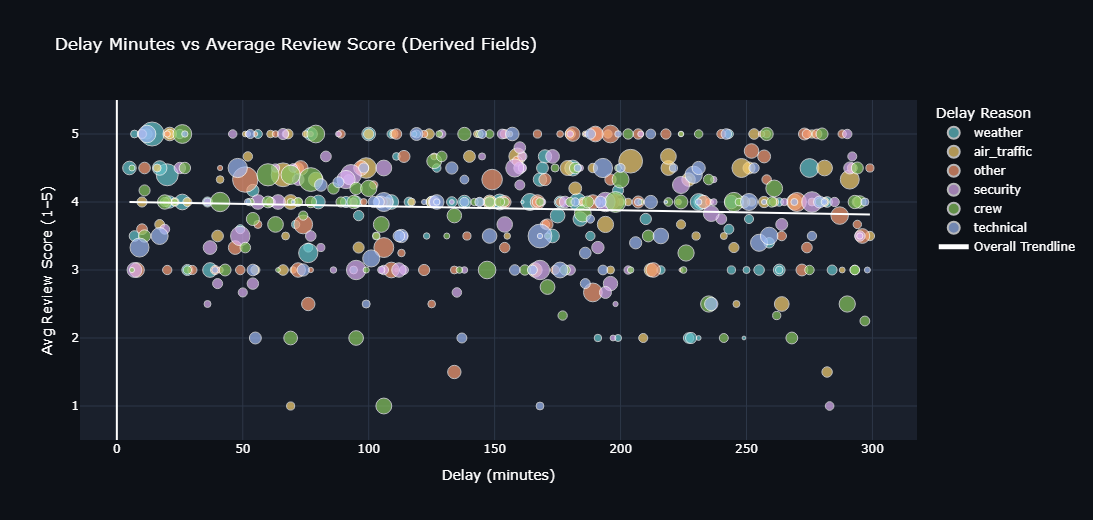

In [25]:
fig5 = px.scatter(
    df_delay,
    x='delay_minutes',
    y='avg_review_score',
    color='delay_reason',
    size='occupancy_rate',
    size_max=18,
    hover_data=['flight_number', 'airline', 'occupancy_rate'],
    trendline='ols',
    trendline_scope='overall',
    trendline_color_override='white',
    labels={
        'delay_minutes':    'Delay (minutes)',
        'avg_review_score': 'Avg Review Score (1–5)',
        'delay_reason':     'Delay Reason',
        'occupancy_rate':   'Occupancy Rate (%)',
    },
    title='Delay Minutes vs Average Review Score (Derived Fields)',
    color_discrete_sequence=px.colors.qualitative.Pastel,
)

fig5.update_layout(
    plot_bgcolor='#1a202c',
    paper_bgcolor='#0d1117',
    font_color='white',
    height=520,
    xaxis=dict(gridcolor='#2d3748'),
    yaxis=dict(gridcolor='#2d3748', range=[0.5, 5.5]),
)
fig5.show()

---
## Summary

All 5 visualizations read **exclusively from MongoDB** and exercise the **derived fields** computed during migration:

| # | Visualization | Derived Fields Used |
|---|--------------|--------------------|
| 1 | World Route Map | Denormalized origin/destination coordinates |
| 2 | Revenue per km | `revenue_per_km`, `price_category` |
| 3 | Occupancy Distribution | `occupancy_rate` |
| 4 | Loyalty Tier Breakdown | `loyalty_tier`, `total_spent` |
| 5 | Delay vs Review Score | `avg_review_score`, embedded delay data |

In [13]:
client.close()
print('MongoDB connection closed.')

MongoDB connection closed.
